In [37]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# CONFIG

INPUT_FILE = "Thailand_Temperature_Clean.csv"

# จำนวนปีที่จะ Forecast
FORECAST_YEARS = 5

# ใช้ข้อมูล 20% ท้าย Dataset เป็น Test
TEST_RATIO = 0.20

RANDOM_STATE = 42

# ค่าจูน Random Forest
RF_N_ESTIMATORS = 500
RF_MAX_DEPTH = None
RF_MIN_SAMPLES_SPLIT = 2
RF_MIN_SAMPLES_LEAF = 1
RF_MAX_FEATURES = 1.0


In [3]:
# 1. LOAD DATA

print("=" * 70)
print("THAILAND TEMPERATURE FORECAST")
print("=" * 70)

if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(
        f"ไม่พบไฟล์ {INPUT_FILE}\n"
        "กรุณาวาง CSV ไว้ในโฟลเดอร์เดียวกับ Python Script"
    )

df = pd.read_csv(INPUT_FILE)

print("\nDataset:")
print(f"Rows    : {len(df):,}")
print(f"Columns : {list(df.columns)}")


THAILAND TEMPERATURE FORECAST

Dataset:
Rows    : 63
Columns : ['Year', 'Value']


In [4]:
# 2. FIND YEAR COLUMN

year_candidates = [
    "Year",
    "year",
    "YEAR",
    "Date",
    "date"
]

year_col = None

for col in year_candidates:
    if col in df.columns:
        year_col = col
        break

if year_col is None:

    for col in df.columns:

        if "year" in str(col).lower():
            year_col = col
            break

if year_col is None:
    raise ValueError(
        "ไม่พบ Column ปี เช่น Year หรือ year"
    )

In [6]:
# 3. FIND TEMPERATURE COLUMN

temp_candidates = [
    "Temperature",
    "temperature",
    "Temp",
    "temp",
    "Temperature_C",
    "temperature_c",
    "AverageTemperature",
    "Average_Temperature",
    "Value",
    "value"
]

temp_col = None

for col in temp_candidates:
    if col in df.columns:
        temp_col = col
        break

if temp_col is None:

    for col in df.columns:

        col_lower = str(col).lower()

        if (
            "temperature" in col_lower
            or "temp" in col_lower
            or col_lower == "value"
        ):
            temp_col = col
            break

if temp_col is None:
    raise ValueError(
        "ไม่พบ Column อุณหภูมิ เช่น Temperature, Temperature_C หรือ Value"
    )


print("\nDetected columns:")
print(f"Year        : {year_col}")
print(f"Temperature : {temp_col}")



Detected columns:
Year        : Year
Temperature : Value


In [7]:
# 4. PREPARE DATA

data = df[
    [year_col, temp_col]
].copy()

data[year_col] = pd.to_numeric(
    data[year_col],
    errors="coerce"
)

data[temp_col] = pd.to_numeric(
    data[temp_col],
    errors="coerce"
)

# ลบข้อมูลที่ไม่สมบูรณ์
data = data.dropna()

# เปลี่ยนชื่อ
data = data.rename(
    columns={
        year_col: "Year",
        temp_col: "Temperature"
    }
)

# ถ้ามีหลายแถวต่อปี ให้เฉลี่ยเป็นรายปี
data = (
    data
    .groupby("Year", as_index=False)
    ["Temperature"]
    .mean()
)

# เรียงตามปี
data = data.sort_values(
    "Year"
).reset_index(drop=True)


print("\nCleaned data:")
print(
    f"Year range: "
    f"{int(data['Year'].min())} - "
    f"{int(data['Year'].max())}"
)

print(
    f"Total years: {len(data)}"
)



Cleaned data:
Year range: 1961 - 2023
Total years: 63


In [8]:
# 5. CHECK DATA

if len(data) < 10:
    raise ValueError(
        "Dataset มีจำนวนน้อยเกินไป "
        "ควรมีอย่างน้อย 10 ปี"
    )

latest_year = int(
    data["Year"].max()
)


In [9]:
# 6. TRAIN / TEST SPLIT

test_size = max(
    3,
    int(len(data) * TEST_RATIO)
)

train = data.iloc[
    :-test_size
].copy()

test = data.iloc[
    -test_size:
].copy()


print("\n" + "=" * 70)
print("TRAIN / TEST SPLIT")
print("=" * 70)

print(
    f"Train : "
    f"{int(train['Year'].min())} - "
    f"{int(train['Year'].max())}"
)

print(
    f"Test  : "
    f"{int(test['Year'].min())} - "
    f"{int(test['Year'].max())}"
)



TRAIN / TEST SPLIT
Train : 1961 - 2011
Test  : 2012 - 2023


In [10]:
# 7. FEATURES

X_train = train[
    ["Year"]
]

y_train = train[
    "Temperature"
]

X_test = test[
    ["Year"]
]

y_test = test[
    "Temperature"
]



In [11]:
# 8. MODEL 1
# LINEAR REGRESSION

print("\n" + "=" * 70)
print("MODEL 1 : LINEAR REGRESSION")
print("=" * 70)

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_pred = linear_model.predict(
    X_test
)

linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred
    )
)

print(
    f"MAE  : {linear_mae:.4f}"
)

print(
    f"RMSE : {linear_rmse:.4f}"
)



MODEL 1 : LINEAR REGRESSION
MAE  : 0.3195
RMSE : 0.4077


In [38]:
# 9. MODEL 2
# RANDOM FOREST

print("\n" + "=" * 70)
print("MODEL 2 : RANDOM FOREST")
print("=" * 70)

rf_model = RandomForestRegressor(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    min_samples_split=RF_MIN_SAMPLES_SPLIT,
    min_samples_leaf=RF_MIN_SAMPLES_LEAF,
    max_features=RF_MAX_FEATURES,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

print(
    f"MAE  : {rf_mae:.4f}"
)

print(
    f"RMSE : {rf_rmse:.4f}"
)


MODEL 2 : RANDOM FOREST
MAE  : 0.6454
RMSE : 0.7112


In [33]:
# 10. เปรียบเทียบคะแนนความแม่นยำ
# คะแนนสูงหมายถึงโมเดลมีความแม่นยำมากกว่า

mean_actual_temperature = y_test.abs().mean()

linear_accuracy = max(
    0,
    100 * (1 - linear_mae / mean_actual_temperature)
)

rf_accuracy = max(
    0,
    100 * (1 - rf_mae / mean_actual_temperature)
)

comparison = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest"
    ],

    "Accuracy_%": [
        linear_accuracy,
        rf_accuracy
    ]

})

# เรียงจากคะแนนความแม่นยำสูงไปต่ำ
comparison = comparison.sort_values(
    "Accuracy_%",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 70)
print("คะแนนความแม่นยำของโมเดล")
print("=" * 70)

print(
    comparison.to_string(
        index=False,
        formatters={
            "Accuracy_%": "{:.2f}%".format
        }
    )
)



คะแนนความแม่นยำของโมเดล
            Model Accuracy_%
Linear Regression     72.25%
    Random Forest     43.94%


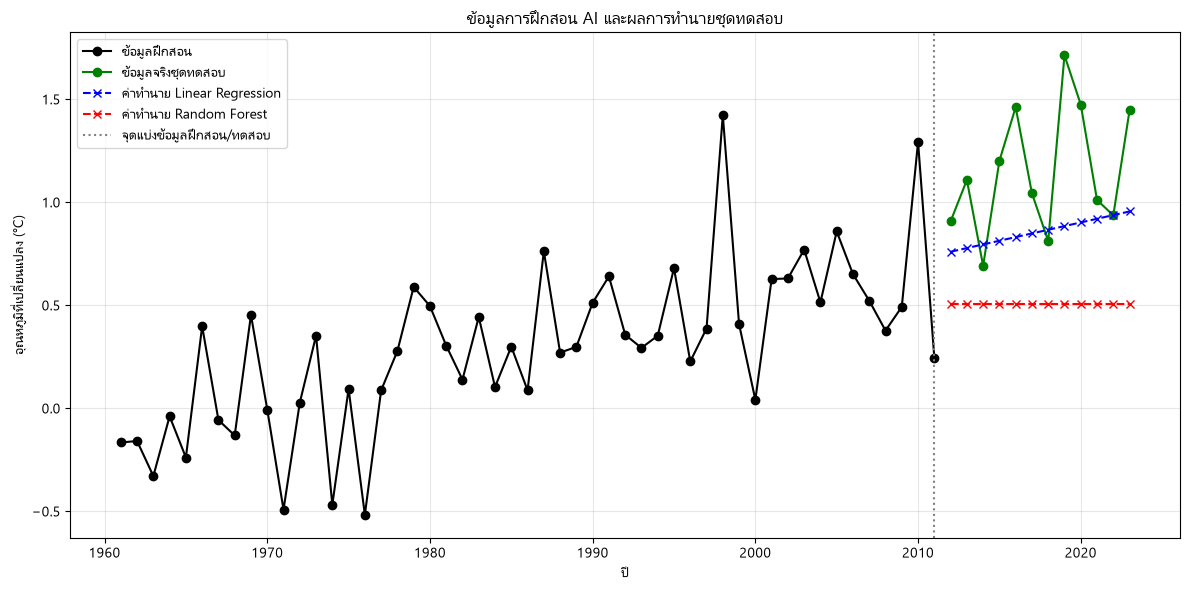

บันทึกไฟล์กราฟแล้ว: Thailand_AI_Training_Results.png


In [32]:
# 10.1. กราฟข้อมูลการฝึกสอน AI

plt.rcParams["font.family"] = "Leelawadee UI"

plt.figure(
    figsize=(12, 6)
)

# ข้อมูลจริงที่ใช้ฝึกสอน
plt.plot(
    train["Year"],
    train["Temperature"],
    marker="o",
    color="black",
    label="ข้อมูลฝึกสอน"
)

# ข้อมูลจริงสำหรับทดสอบ
plt.plot(
    test["Year"],
    test["Temperature"],
    marker="o",
    color="green",
    label="ข้อมูลจริงชุดทดสอบ"
)

# ค่าที่โมเดลทำนายจากชุดทดสอบ
plt.plot(
    test["Year"],
    linear_pred,
    marker="x",
    linestyle="--",
    color="blue",
    label="ค่าทำนาย Linear Regression"
)

plt.plot(
    test["Year"],
    rf_pred,
    marker="x",
    linestyle="--",
    color="red",
    label="ค่าทำนาย Random Forest"
)

plt.axvline(
    train["Year"].max(),
    linestyle=":",
    color="gray",
    label="จุดแบ่งข้อมูลฝึกสอน/ทดสอบ"
)

plt.title(
    "ข้อมูลการฝึกสอน AI และผลการทำนายชุดทดสอบ"
)

plt.xlabel(
    "ปี"
)

plt.ylabel(
    "อุณหภูมิที่เปลี่ยนแปลง (°C)"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

training_graph_file = (
    "Thailand_AI_Training_Results.png"
)

plt.savefig(
    training_graph_file,
    dpi=300
)

plt.show()

print(
    f"บันทึกไฟล์กราฟแล้ว: {training_graph_file}"
)


In [36]:
# 11. SAVE MODEL COMPARISON

comparison_file = (
    "Thailand_Model_Comparison.csv"
)

comparison.to_csv(
    comparison_file,
    index=False,
    encoding="utf-8-sig"
)

print(
    f"\nSaved: {comparison_file}"
)



Saved: Thailand_Model_Comparison.csv


In [34]:
# 12. เลือกโมเดลที่มีคะแนนความแม่นยำสูงสุด

best_model = comparison.iloc[0]["Model"]

print("\n" + "=" * 70)
print("เลือกโมเดล")
print("=" * 70)

print(
    f"โมเดลที่เลือก: {best_model}"
)

print(
    "เกณฑ์การเลือก: คะแนนความแม่นยำสูงกว่า"
)



เลือกโมเดล
โมเดลที่เลือก: Linear Regression
เกณฑ์การเลือก: คะแนนความแม่นยำสูงกว่า


In [39]:
# 13. TRAIN FINAL MODELS
# ใช้ข้อมูลทั้งหมด

X_all = data[
    ["Year"]
]

y_all = data[
    "Temperature"
]


# ------------------------------------------------------------
# Linear Regression
# ------------------------------------------------------------

final_linear = LinearRegression()

final_linear.fit(
    X_all,
    y_all
)


# ------------------------------------------------------------
# Random Forest
# ใช้ค่าจูนเดียวกับโมเดลที่ประเมินผล
# ------------------------------------------------------------

final_rf = RandomForestRegressor(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    min_samples_split=RF_MIN_SAMPLES_SPLIT,
    min_samples_leaf=RF_MIN_SAMPLES_LEAF,
    max_features=RF_MAX_FEATURES,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

final_rf.fit(
    X_all,
    y_all
)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [17]:
# 14. CREATE FUTURE YEARS

future_years = np.arange(
    latest_year + 1,
    latest_year + FORECAST_YEARS + 1
)

future_X = pd.DataFrame({
    "Year": future_years
})


print("\nForecast years:")

for year in future_years:
    print(year)



Forecast years:
2024
2025
2026
2027
2028


In [18]:
# 15. FORECAST

linear_forecast = final_linear.predict(
    future_X
)

rf_forecast = final_rf.predict(
    future_X
)


In [19]:
# 16. SELECT FORECAST

if best_model == "Linear Regression":

    selected_forecast = linear_forecast

else:

    selected_forecast = rf_forecast


In [24]:
# 17. CREATE FORECAST DATAFRAME

latest_temperature = data.loc[
    data["Year"].idxmax(),
    "Temperature"
]

forecast_df = pd.DataFrame({

    "Year": future_years,

    "Current_Dataset_Temperature_Change_C": latest_temperature,

    "Linear_Regression_Temperature_Change_C": linear_forecast,

    "Random_Forest_Temperature_Change_C": rf_forecast,

    "Forecast_Temperature_Change_C": selected_forecast

})


forecast_df["Forecast_Model"] = best_model


# เปรียบเทียบอุณหภูมิที่เปลี่ยนแปลงกับค่าล่าสุดของ dataset เป็นเปอร์เซ็นต์
forecast_df["Linear_Regression_Change_vs_Current_%"] = (
    (
        forecast_df["Linear_Regression_Temperature_Change_C"]
        - latest_temperature
    )
    / latest_temperature
    * 100
)

forecast_df["Random_Forest_Change_vs_Current_%"] = (
    (
        forecast_df["Random_Forest_Temperature_Change_C"]
        - latest_temperature
    )
    / latest_temperature
    * 100
)

forecast_df["Forecast_Change_vs_Current_%"] = (
    (
        forecast_df["Forecast_Temperature_Change_C"]
        - latest_temperature
    )
    / latest_temperature
    * 100
)


# ปัดทศนิยม
for col in [
    "Current_Dataset_Temperature_Change_C",
    "Linear_Regression_Temperature_Change_C",
    "Random_Forest_Temperature_Change_C",
    "Forecast_Temperature_Change_C",
    "Linear_Regression_Change_vs_Current_%",
    "Random_Forest_Change_vs_Current_%",
    "Forecast_Change_vs_Current_%"
]:

    forecast_df[col] = forecast_df[col].round(3)


In [26]:
# 18. SAVE FORECAST

forecast_file = (
    "Thailand_Temperature_Forecast_2024_2028.csv"
)

forecast_df.to_csv(
    forecast_file,
    index=False,
    encoding="utf-8-sig"
)

In [25]:
# 19. DISPLAY FORECAST

print("\n" + "=" * 70)
print("FORECAST TEMPERATURE CHANGE")
print("=" * 70)

forecast_display = forecast_df[
    [
        "Year",
        "Current_Dataset_Temperature_Change_C",
        "Forecast_Temperature_Change_C",
        "Forecast_Model",
        "Forecast_Change_vs_Current_%"
    ]
].rename(
    columns={
        "Current_Dataset_Temperature_Change_C": "Current_Dataset_Change_C",
        "Forecast_Temperature_Change_C": "Forecast_Change_C",
        "Forecast_Change_vs_Current_%": "Change_vs_Current_%"
    }
)

print(
    forecast_display.to_string(
        index=False
    )
)

print(
    f"\nหมายเหตุ: ค่า Forecast_Change_C คืออุณหภูมิที่เปลี่ยนแปลง (องศาเซลเซียส)"
)

print(
    f"Saved: {forecast_file}"
)



FORECAST TEMPERATURE CHANGE
 Year  Current_Dataset_Change_C  Forecast_Change_C    Forecast_Model  Change_vs_Current_%
 2024                     1.447              1.170 Linear Regression              -19.143
 2025                     1.447              1.192 Linear Regression              -17.612
 2026                     1.447              1.214 Linear Regression              -16.081
 2027                     1.447              1.236 Linear Regression              -14.550
 2028                     1.447              1.259 Linear Regression              -13.018

หมายเหตุ: ค่า Forecast_Change_C คืออุณหภูมิที่เปลี่ยนแปลง (องศาเซลเซียส)
Saved: Thailand_Temperature_Forecast_2024_2028.csv


In [ ]:
# 20. CREATE GRAPH

plt.figure(
    figsize=(12, 6)
)

# Actual
plt.plot(
    data["Year"],
    data["Temperature"],
    marker="o",
    label="Actual"
)

# Linear Regression
plt.plot(
    future_years,
    linear_forecast,
    marker="o",
    linestyle="--",
    label="Linear Regression"
)

# Random Forest
plt.plot(
    future_years,
    rf_forecast,
    marker="o",
    linestyle="--",
    label="Random Forest"
)

# จุดเริ่ม Forecast
plt.axvline(
    latest_year,
    linestyle=":",
    label="Forecast Start"
)

plt.title(
    "Thailand Temperature Forecast"
)

plt.xlabel(
    "Year"
)

plt.ylabel(
    "Temperature (°C)"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()


graph_file = (
    "Thailand_Temperature_Forecast.png"
)

plt.savefig(
    graph_file,
    dpi=300
)

plt.show()



In [ ]:
# 21. FINAL SUMMARY

print("\n" + "=" * 70)
print("COMPLETED")
print("=" * 70)

print(
    f"Latest Dataset Year : {latest_year}"
)

print(
    f"Forecast            : "
    f"{latest_year + 1} - "
    f"{latest_year + FORECAST_YEARS}"
)

print(
    f"Best Model          : {best_model}"
)

print(
    f"\nOutput files:"
)

print(
    f"1. {forecast_file}"
)

print(
    f"2. {comparison_file}"
)

print(
    f"3. {graph_file}"
)

print("\nDone.")

In [28]:
# แสดงผลลัพธ์การพยากรณ์

print("ผลการพยากรณ์อุณหภูมิ")
print("=" * 70)

display(
    forecast_df[
        [
            "Year",
            "Current_Dataset_Temperature_Change_C",
            "Forecast_Temperature_Change_C",
            "Forecast_Model",
            "Forecast_Change_vs_Current_%"
        ]
    ]
)

ผลการพยากรณ์อุณหภูมิ


,Year,Current_Dataset_Temperature_Change_C,Forecast_Temperature_Change_C,Forecast_Model,Forecast_Change_vs_Current_%
0,2024,1.447,1.170,Linear Regression,-19.143
1,2025,1.447,1.192,Linear Regression,-17.612
2,2026,1.447,1.214,Linear Regression,-16.081
3,2027,1.447,1.236,Linear Regression,-14.550
4,2028,1.447,1.259,Linear Regression,-13.018


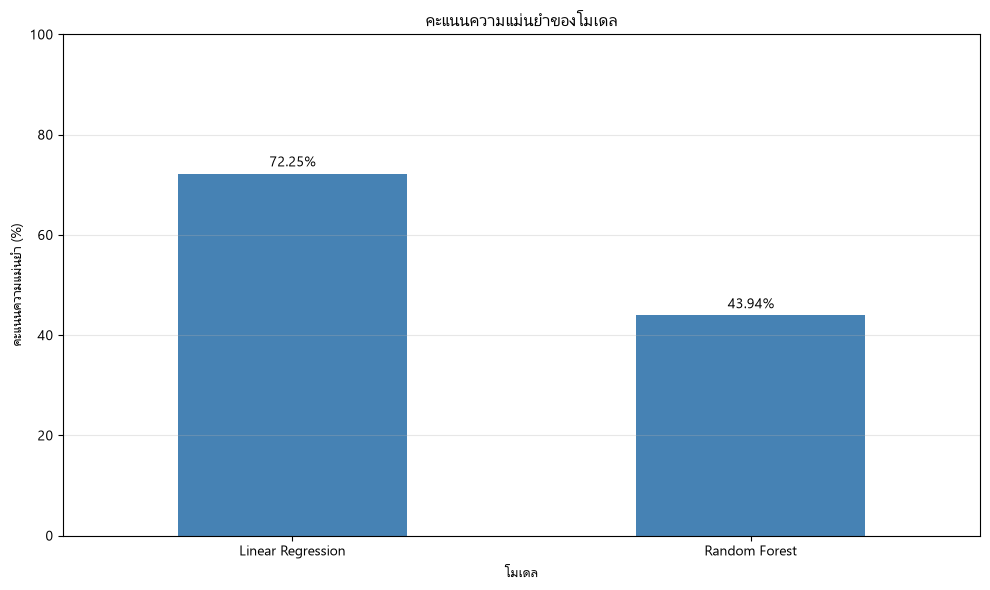

โมเดลที่มีคะแนนความแม่นยำสูงสุด: Linear Regression


In [35]:
# กราฟคะแนนความแม่นยำของโมเดล
# คะแนนยิ่งสูง แสดงว่าโมเดลยิ่งแม่นยำ

plt.rcParams["font.family"] = "Leelawadee UI"

accuracy_scores = comparison.set_index("Model")[["Accuracy_%"]]

ax = accuracy_scores.plot(
    kind="bar",
    figsize=(10, 6),
    color="steelblue",
    legend=False
)

plt.title("คะแนนความแม่นยำของโมเดล")
plt.xlabel("โมเดล")
plt.ylabel("คะแนนความแม่นยำ (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

print(
    f"โมเดลที่มีคะแนนความแม่นยำสูงสุด: {best_model}"
)
